# Análisis Exploratorio de Datos (EDA): Mercado Inmobiliario de California

## 1. Contexto y Objetivo
El presente análisis examina un conjunto de datos correspondiente al mercado inmobiliario del estado de California, con el fin de identificar y medir las principales variables que influyen en el precio de las viviendas. El enfoque va más allá de la simple descripción de los datos: se busca detectar irregularidades en su estructura, generar nuevas variables derivadas y revelar patrones que no son evidentes en un análisis superficial.

## 2. Resumen Ejecutivo
* **Ingreso como predictor clave:** El ingreso mediano del vecindario (`median_income`) resultó ser la variable con mayor poder explicativo sobre el precio de vivienda.
* **Irregularidades en los datos:** Se encontraron valores límite artificiales en las columnas de precio ($500,001) y edad de la vivienda (52 años) que distorsionan la distribución real del mercado.
* **Importancia de la distribución interna de las viviendas:** La proporción de dormitorios respecto al total de ambientes (`bedrooms_per_room`) mostró que los inmuebles más costosos reservan menos espacio para dormitorios y más para áreas comunes.


## 3. Carga e Inspección Inicial

In [ ]:
# Importar librerías necesarias para todo el análisis
import pandas as pd        
import numpy as np        
import matplotlib.pyplot as plt
import seaborn as sns      
import warnings
import kagglehub           

# Silenciar advertencias que no afectan el análisis
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Config. estilo de los gráficos con fondo de cuadrícula blanca
sns.set_theme(style='whitegrid')

# Establecer tamaño por defecto de las figuras 
plt.rcParams['figure.figsize'] = (12, 6)

# Magic command para mostrar gráficos inline en el notebook
%matplotlib inline

In [2]:
# Descargar el dataset directamente desde Kaggle
import os
dataset_path = kagglehub.dataset_download('camnugent/california-housing-prices')
df = pd.read_csv(os.path.join(dataset_path, 'housing.csv'))

# Mostrar las primeras 10 filas para ver la estructura de los datos
print('Vista previa de datos:')
display(df.head(10))

# Mostrar información técnica: tipos de datos, nulos por columna, uso de memoria
print('Estructura y tipo de datos:')
df.info()

# Mostrar dimensiones: (filas, columnas)
print('Dimensiones del dataset:')
df.shape

Vista previa de datos:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Estructura y tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Dimensiones del dataset:


(20640, 10)

## 4. Análisis Univariado: La Variable Objetivo (Precios)
Exploración de la distribución de `median_house_value` para detectar anomalías, sesgos y la morfología general del mercado inmobiliario.

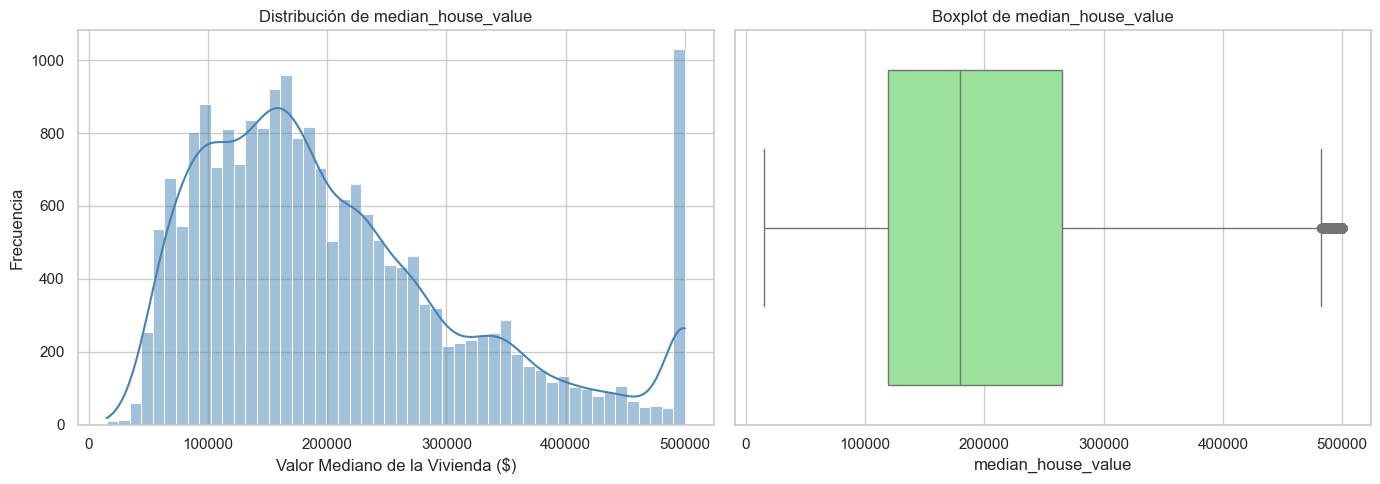

In [ ]:
# config. de matplotlib (dos subplots en paralelo: hist. y boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot izquierdo: histograma con curva KDE (estimación de densidad)
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue', ax=axes[0]) # ax indice 0
axes[0].set_title('Distribución de median_house_value')
axes[0].set_xlabel('Valor Mediano de la Vivienda ($)')
axes[0].set_ylabel('Frecuencia')

# Subplot derecho: boxplot para detectar outliers visualmente
# La caja muestra Q1-Q3, la línea media es la mediana
# Los "bigotes" se extienden 1.5*IQR, puntos fuera son outliers
sns.boxplot(x=df['median_house_value'], color='lightgreen', ax=axes[1]) # ax indice 1 
axes[1].set_title('Boxplot de median_house_value')

# ajustamos espaciado entre subplots
plt.tight_layout()
plt.show()

**Hallazgo:** la distribución es asimétrica a la derecha y muestra un pico artificial en $500k: el techo del dataset acumula ahí todos los distritos que en realidad valen más. El boxplot confirma que ese pico no es un outlier común sino un corte estructural.

## 5. Análisis Univariado: El Poder Adquisitivo (Ingresos)
Exploración de la distribución de `median_income` para entender la distribución de riqueza.

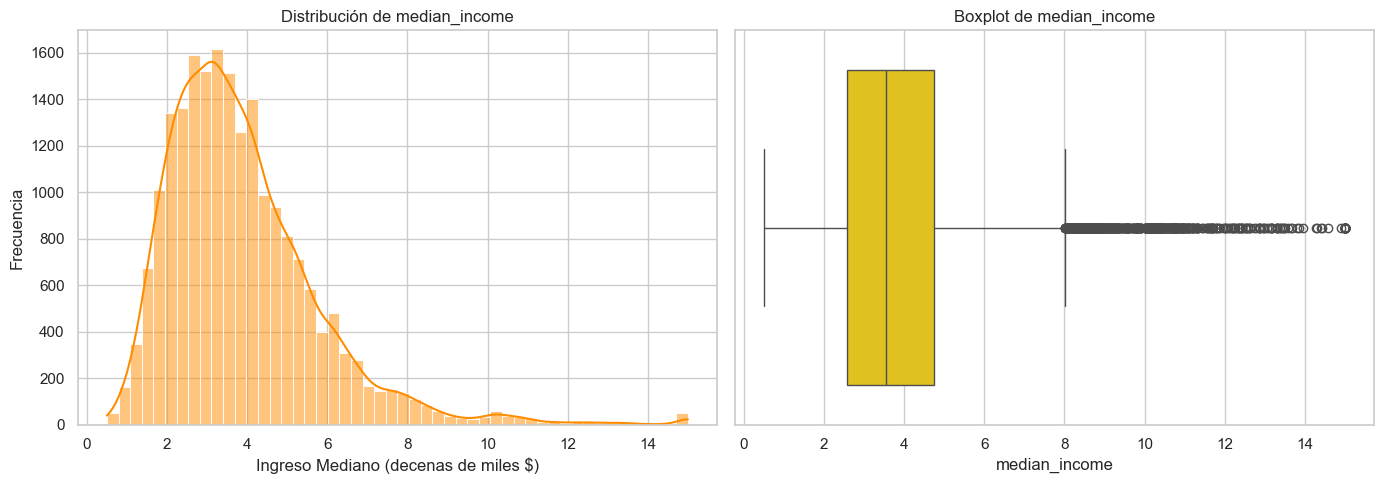

In [ ]:
# config. de matplotlib (dos subplots en paralelo: hist. y boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE de la media de ingresos
sns.histplot(df['median_income'], bins=50, kde=True, color='darkorange', ax=axes[0])
axes[0].set_title('Distribución de median_income')
axes[0].set_xlabel('Ingreso Mediano (decenas de miles $)')
axes[0].set_ylabel('Frecuencia')

# Boxplot del ingreso para ver dispersión y outliers
sns.boxplot(x=df['median_income'], color='gold', ax=axes[1])
axes[1].set_title('Boxplot de median_income')

plt.tight_layout()
plt.show()

**Hallazgo:** el ingreso está expresado en decenas de miles de dólares, con media ~3.87 (≈$38.700). También tiene cola derecha y un mini-pico en su techo (~15.0001), aunque solo afecta al 0.24% de las filas.

## 6. Análisis Bivariado: Ingresos vs Precios
Scatter plot para evaluar la relación lineal entre capacidad económica y valor de vivienda.

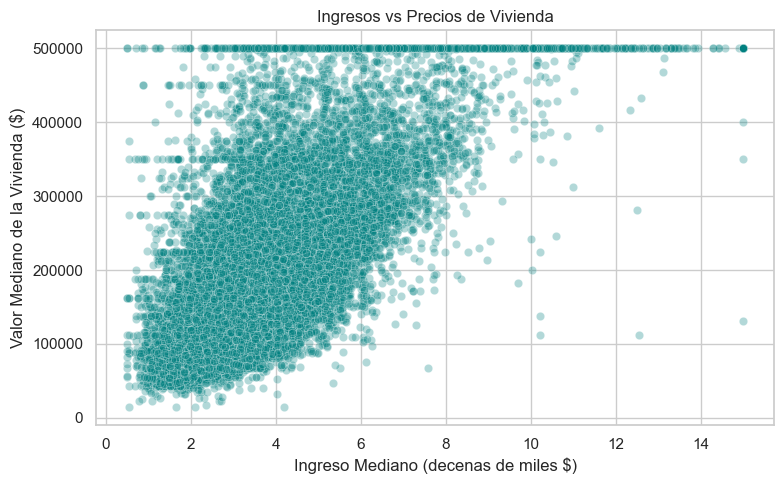

In [ ]:
plt.figure(figsize=(8, 5))

# Scatter plot: eje X = ingreso, eje Y = precio
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='teal')
plt.title('Ingresos vs Precios de Vivienda')
plt.xlabel('Ingreso Mediano (decenas de miles $)')
plt.ylabel('Valor Mediano de la Vivienda ($)')
plt.tight_layout()
plt.show()

**Hallazgo:** relación positiva clara: a mayor ingreso del distrito, mayor precio de vivienda. La dispersión aumenta con el ingreso, y se observa el techo artificial en $500k como una línea horizontal.

## 7. Verificación de Techos Artificiales
Los valores máximos del dataset no son reales: son **techos artificiales** impuestos al publicar los datos. Se detectan contando cuántas filas quedan pegadas exactamente al máximo de cada columna.

In [6]:
# Detectar techo artificial en median_house_value
# La variable objetivo tiene un valor máximo artificial de $500,001 que corta la distribución
precio_max = df['median_house_value'].max()
bloques_tope_precio = df[df['median_house_value'] == precio_max]
porcentaje_precio_tope = (len(bloques_tope_precio) / len(df)) * 100
print(f'Reporte de posible anomalia (median_house_value)')
print(f'  Valor maximo detectado: ${precio_max:,.0f}')
print(f'  Bloques con valor maximo: {len(bloques_tope_precio)} ({porcentaje_precio_tope:.2f}%)')
print()

# Detectar techo artificial en housing_median_age
edad_max = df['housing_median_age'].max()
bloques_tope_edad = df[df['housing_median_age'] == edad_max]
porcentaje_edad_tope = (len(bloques_tope_edad) / len(df)) * 100
print(f'Reporte de posible anomalia (housing_median_age)')
print(f'  Valor maximo detectado: {edad_max}')
print(f'  Bloques con valor maximo: {len(bloques_tope_edad)} ({porcentaje_edad_tope:.2f}%)')
print()

# Detectar techo artificial en median_income
ingreso_max = df['median_income'].max()
bloques_tope_ingresos = df[df['median_income'] == ingreso_max]
porcentaje_ingreso_tope = (len(bloques_tope_ingresos) / len(df)) * 100
print(f'Reporte de posible anomalia (median_income)')
print(f'  Valor maximo detectado: {ingreso_max}')
print(f'  Bloques con valor maximo: {len(bloques_tope_ingresos)} ({porcentaje_ingreso_tope:.2f}%)')
print()

# Almacenar los valores de corte para uso posterior en la limpieza
print(f'Valores de corte guardados para limpieza:')

Reporte de posible anomalia (median_house_value)
  Valor maximo detectado: $500,001
  Bloques con valor maximo: 965 (4.68%)

Reporte de posible anomalia (housing_median_age)
  Valor maximo detectado: 52.0
  Bloques con valor maximo: 1273 (6.17%)

Reporte de posible anomalia (median_income)
  Valor maximo detectado: 15.0001
  Bloques con valor maximo: 49 (0.24%)

Valores de corte guardados para limpieza:


**Hallazgo:** hay tres techos artificiales: `median_house_value` en 500,001 (~4.7%), `housing_median_age` en 52 años (~6.2%) y `median_income` en ~15.0001 (~0.2%). El del precio es el más grave porque **trunca la variable objetivo**.